# Projeto Parte 2

### Aluno: Denise Almeida de Souza

# Instalação de Pacotes

In [238]:
install.packages(c("readxl", "skimr", "ggplot2", "tidyverse" ), dep=TRUE) 
library(readxl)
library(knitr)
library(ggplot2)
library(skimr)
library(tidyverse)
library(MASS)


Os pacotes binários baixados estão em
	/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T//Rtmpy8SZLq/downloaded_packages


# Leitura e tratamento dos dados

In [239]:
url0 <- 'https://raw.githubusercontent.com/filipezabala/pucrs-tecnologo-bd/main/dados/Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv'
fifa <- read.csv(url0, sep = ';', encoding = 'latin1')
str(fifa)

'data.frame':	718 obs. of  30 variables:
 $ id                           : int  158023 153079 211110 201399 226226 199667 212616 216816 183892 231478 ...
 $ name                         : chr  "Messi" "Aguero" "Dybala" "Icardi" ...
 $ full_name                    : chr  "Lionel Andrés Messi Cuccittini" "Sergio Leonel Agüero del Castillo" "Paulo Bruno Exequiel Dybala" "Mauro Emanuel Icardi Rivero" ...
 $ overall_rating               : int  94 89 89 87 82 77 77 78 79 79 ...
 $ value_euro                   : int  110500000 64500000 89000000 64500000 30000000 8500000 12000000 15000000 8500000 18000000 ...
 $ wage_euro                    : int  565000 300000 205000 130000 83000 28000 27000 53000 19000 54000 ...
 $ nationality                  : chr  "Argentina" "Argentina" "Argentina" "Argentina" ...
 $ national_team                : chr  "Argentina" "Argentina" "Argentina" "Argentina" ...
 $ club_team                    : chr  "FC Barcelona" "Manchester City" "Juventus" "Inter" ...
 $ age 

### Avaliando a descrição das variáveis

In [240]:
descriptions <- read_excel("../data/raw/data_dictionary.xlsx")
View(descriptions)

Variable,Descricao
<chr>,<chr>
id,Número de identificacao
name,Nome resumido do jogador
full_name,Nome completo do jogador
overall_rating,Escore de avaliacao geral de 0-100
value_euro,Valor do jogador no mercado (Euros)
wage_euro,Salario em Euros
nationality,nacionalidade
national_team,Selecao na qual atua
club_team,Clube no qual atua


In [241]:
names(fifa)

[1] "id"                            "name"                         
 [3] "full_name"                     "overall_rating"               
 [5] "value_euro"                    "wage_euro"                    
 [7] "nationality"                   "national_team"                
 [9] "club_team"                     "age"                          
[11] "height_cm"                     "weight_kgs"                   
[13] "international_reputation.1.5." "weak_foot.1.5."               
[15] "skill_moves.1.5."              "club_rating"                  
[17] "Goleiro"                       "Zagueiro"                     
[19] "Meio"                          "Atacante"                     
[21] "crossing"                      "finishing"                    
[23] "heading_accuracy"              "short_passing"                
[25] "dribbling"                     "jumping"                      
[27] "strength"                      "long_shots"                   
[29] "aggression"                    "GK_reflexes"

# Estatísticas Descritivas

In [242]:
fltr_num <- sapply(fifa, is.integer)
summary(fifa[,fltr_num])

       id         overall_rating    value_euro          wage_euro     
 Min.   : 20801   Min.   :58.00   Min.   :   230000   Min.   :  1000  
 1st Qu.:189831   1st Qu.:72.00   1st Qu.:  3325000   1st Qu.: 10000  
 Median :204626   Median :76.00   Median :  8000000   Median : 27000  
 Mean   :203668   Mean   :76.46   Mean   : 13897695   Mean   : 49560  
 3rd Qu.:222200   3rd Qu.:80.00   3rd Qu.: 17000000   3rd Qu.: 59000  
 Max.   :246387   Max.   :94.00   Max.   :110500000   Max.   :565000  
      age          height_cm     weight_kgs     international_reputation.1.5.
 Min.   :18.00   Min.   :152   Min.   : 59.00   Min.   :1.000                
 1st Qu.:24.00   1st Qu.:170   1st Qu.: 73.00   1st Qu.:1.000                
 Median :26.00   Median :183   Median : 77.00   Median :1.000                
 Mean   :26.57   Mean   :177   Mean   : 77.67   Mean   :1.673                
 3rd Qu.:29.00   3rd Qu.:188   3rd Qu.: 82.00   3rd Qu.:2.000                
 Max.   :37.00   Max.   :203   Max.

# Exercícios do projeto:


### 1) Cálculo de probabilidades condicionais e incondicionais de pelo menos duas variáveis selecionadas pelo aluno, interpretando corretamente o seu significado.


##### Probabilidade Incondicional: Atacantes

In [243]:
(tab <- table(fifa$Atacante))


  0   1 
646  72 

##### Portanto, a probabilidade de um jogador ser atacante é de $P(\text{1 - Atacante})=\frac{72}{718} \approx ~0.1003$. De um jogador ser não atacante é de $P(\text{0 - Não atacante})=1-\frac{646}{718} \approx 0.8997$.

In [244]:
(n <- sum(tab))

round(p4 <- tab[1]/n, 4)
round(p2 <- tab[2]/n, 4)

MASS::fractions(p4)
MASS::fractions(p2)

[1] 718

0 
0.8997

1 
0.1003

0 
323/359

1 
36/359

##### Probabilidade Condicional: Habilidade de movimento por posição de Zagueiro. 

In [245]:
tab2 <- table(fifa$skill_moves.1.5., fifa$Zagueiro)
(tab2 <- addmargins(tab2))

,0,1,Sum
1,82,0,82
2,150,9,159
3,281,39,320
4,138,6,144
5,13,0,13
Sum,664,54,718


In [246]:
round((p5_zagueiro <- tab2[3, 2] / tab2[6, 2]),4)
round((p_nao5_zagueiro <- 1 - p5_zagueiro), 4)

[1] 0.7222

[1] 0.2778

#### A probabilidade de um zagueiro ter 3 estrelas em habilidade de movimento é $P(\text{1 - Zagueiro})=\frac{39}{54} \approx ~0.7222$. E a probabilidade de não ser zagueiro é $P(\text{0 - Não Zagueiro})=\frac{281}{54} \approx ~0.2778$.


### 2) Intervalos de confiança e sua interpretação para pelo menos duas variáveis selecionadas.

In [247]:
result <- t.test(fifa$height_cm)
ic <- result$conf.int
round(ic,4)

[1] 175.9747 178.0726
attr(,"conf.level")
[1] 0.95

In [248]:
# Manual
m <- mean(fifa$height_cm)
s <- sd(fifa$height_cm)
n <- length(fifa$height_cm)
round((LI <- m-abs(qt(0.025,n-1))*s/sqrt(n)),4)
round((LS <- m+abs(qt(0.025,n-1))*s/sqrt(n)),4)

[1] 175.9747

[1] 178.0726

##### O intervalo de confiança para o atributo height_cm possui valores entre 175.97cm (1.75m) e 178.07cm (1.78m).

In [249]:
result <- t.test(fifa$weight_kgs)
ic <- result$conf.int
round(ic,4)

[1] 77.1393 78.2089
attr(,"conf.level")
[1] 0.95

In [250]:
#Manual
m <- mean(fifa$weight_kgs)
s <- sd(fifa$weight_kgs)
n <- length(fifa$weight_kgs)
round((LI <- m-abs(qt(0.025,n-1))*s/sqrt(n)),4)
round((LS <- m+abs(qt(0.025,n-1))*s/sqrt(n)),4)

[1] 77.1393

[1] 78.2089

##### O intervalo de confiança para o atributo weight_kgs possui os valores entre 77.13kg e 78.20kg

### 3) Testes de hipóteses e sua interpretação para pelo menos duas variáveis selecionadas pelo aluno. As hipóteses devem avaliar se a média populacional da referida variável pode ser considerada igual à média amostral arredondada para o inteiro. 

In [251]:
summary(fifa$weight_kgs)
(ma <- round(mean(fifa$weight_kgs),0))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  59.00   73.00   77.00   77.67   82.00  100.00 

[1] 78

##### Podemos testar a hipotese se a média do peso pode ser considerada igual a sua média amostral arredondada no inteiro, no caso 78. Formalmente $H_0: \mu = 78$ *vs* $H_1: \mu \ne 78$.   


In [252]:
t.test(fifa$height_cm,
       mu = ma)


	One Sample t-test

data:  fifa$height_cm
t = 185.34, df = 717, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 78
95 percent confidence interval:
 175.9747 178.0726
sample estimates:
mean of x 
 177.0237 


##### Como p-value < 2.2e-16 está muito próximo de 0 nós rejeitamos a hipótese $H_0: \mu = 78$.

In [253]:
summary(fifa$international_reputation.1.5.)
(ma <- round(mean(fifa$international_reputation.1.5.),0))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   1.673   2.000   5.000 

[1] 2

##### Podemos testar a hipotese se a média do peso pode ser considerada igual a sua média amostral arredondada no inteiro, no caso 2. Formalmente $H_0: \mu = 2$ *vs* $H_1: \mu \ne 2$.   


In [254]:
t.test(fifa$international_reputation.1.5.,
       mu = ma)


	One Sample t-test

data:  fifa$international_reputation.1.5.
t = -9.8355, df = 717, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 2
95 percent confidence interval:
 1.607369 1.738035
sample estimates:
mean of x 
 1.672702 


#### Como p-value < 2.2e-16 está muito próximo de 0 nós rejeitados a hipótese $H_0: \mu = 2$.

### 4) Análise de Regressão (simples ou múltipla) sobre variáveis que deverão ser escolhidas pelo autor do trabalho. O aluno deve interpretar os coeficientes OU realizar predições com os modelos selecionados, bem como indicar minimamente os diagnósticos realizados.


Call:
lm(formula = overall_rating ~ age, data = fifa)

Residuals:
     Min       1Q   Median       3Q      Max 
-16.4118  -4.2209  -0.5012   4.0276  16.1549 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 68.16951    1.65049  41.302  < 2e-16 ***
age          0.31212    0.06157   5.069 5.09e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.917 on 716 degrees of freedom
Multiple R-squared:  0.03465,	Adjusted R-squared:  0.0333 
F-statistic:  25.7 on 1 and 716 DF,  p-value: 5.091e-07



	Shapiro-Wilk normality test

data:  fit$residuals
W = 0.99489, p-value = 0.0168


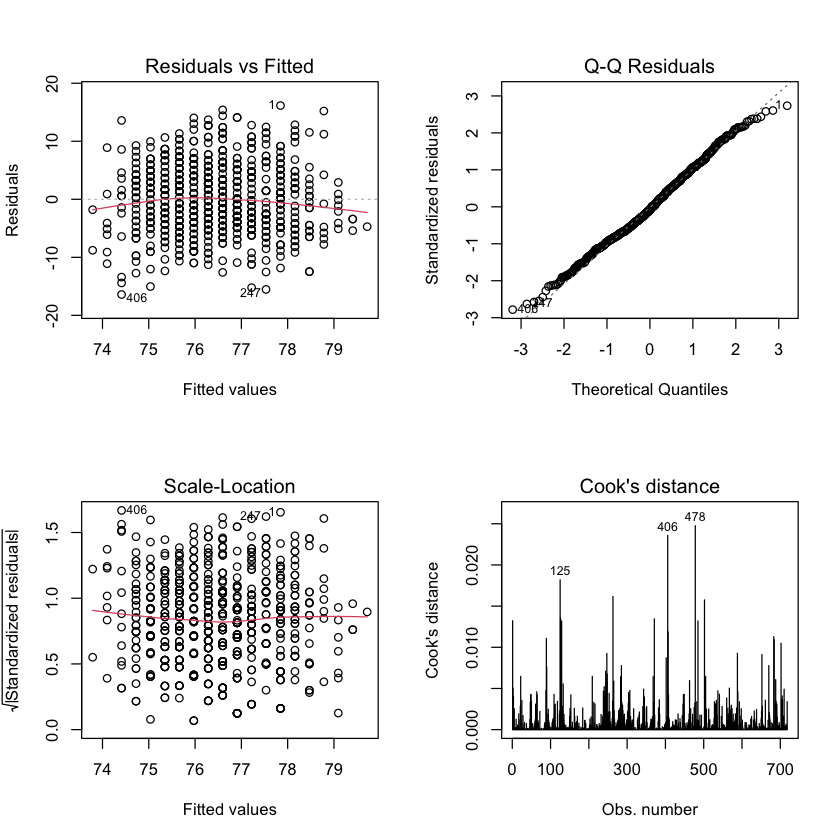

In [255]:
# Regressão linear simples
fit <- lm(overall_rating ~ age, data = fifa)
summary(fit)

shapiro.test(fit$residuals)
par(mfrow = c(2,2))
plot(fit, which = 1:4)




##### Calculada a regressão linear simples da avaliação geral dos jogadores em relação a sua idade, o coeficiênte estimado do overall_rating dos jogadores é de  (`Intercept = 68.16951`) e o coeficiênte de idade(age) é de 0.31212. Isso indica que em média a cada ano de idade(age), a avaliacão geral do jogador aumenta em aproximadamente 0.31 pontos.

##### Sobre o R-squared sendo de apenas 0.034, ou seja, 3,4% da variação de overall_rating é explicada pela idade (age), informando que apenas a idade(age) não é um bom preditor de desempenho geral. 

##### - O gráfico de resíduos x valores ajustados não mostrou tendência de crescimento ou decrescimento, se mantendo como um modelo linear.
##### - O gráfico Q-Q Residuals possui alinhamento razoável exceto com os pequenos desvios nas caudas.
##### - O gráfico Scale-Location possui uma variança dos resíduos, mantendo constância.
##### - A distância de Cook apontou observações influentes (125,406 e 478) mas que não comprometem o modelo.


##### Conclusão: Mesmo existindo relação entre a idade (age) e overall_rating, a baixa capacidade explicativa do modelo indica que outras variáveis devem ser consideradas.

### 5) Elaboração de três frases (manchetes) de efeito, associadas aos resultados observados. 

##### 5.1) A consistência ao passar dos anos conta na sua avaliacao geral, Jogador!

Detalhes: A regressão linear simples indicou que a cada ano de idade, o overall_rating de um jogador aumenta em média 0,31 pontos, embora a idade explique apenas 3,4% da variação no desempenho. Dados na seção 4. (`estimate =  0.31212 ` ) 

##### 5.2) Tem que crescer, Jogador!

Detalhes: O intervalo de confiança para a variável height_cm mostrou que a altura média dos jogadores está concentrada em um intervalo estreito, sugerindo baixa variabilidade nesse atributo físico. Dados na seção 2. (`IC = 175.97cm (1.75m) e 178.07cm (1.78m)`)

##### 5.3) Ser zagueiro reduz a chance de brilho nos dribles.

Detalhes: A análise de probabilidade condicional revelou que zagueiros possuem baixa probabilidade de alcançar 5 estrelas em skill moves, reforçando o perfil defensivo em detrimento da habilidade ofensiva. Dados na seção 1. $P(\text{1 - Zagueiro})=\frac{39}{54} \approx ~0.7222$. E  $P(\text{0 - Não Zagueiro})=\frac{281}{54} \approx ~0.2778$.